In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

In [2]:
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)
print(parent_dir)
interpolated_dir = os.path.join(parent_dir, "dataset_interpolated_fixed")
# features = ["game_completed", "relative_strength", "score_difference", "type.id", "home_has_possession", "end.down", "end.yardsToEndzone", "end.distance", "field_position_shift", "home_timeouts_left", "away_timeouts_left"]
features = ["game_completed", "relative_strength", "score_difference", "home_has_possession", "end.down", "end.distance", "end.yardsToEndzone", "home_timeouts_left", "away_timeouts_left", "predicted_drive_points_ev"]
# features = ["relative_strength", "score_difference", "home_has_possession"]

/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML


In [3]:
# Reset the modules
modules_to_reload = [
    'process_data',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

import process_data
training_data = process_data.load_data(interpolated_dir, 
                                       years = [2016, 2017,2018, 2019, 2020, 2021, 2022, 2023], 
                                       history_length = 0, 
                                       features = features, 
                                       label_feature = "home_win")

# validation_data = process_data.load_data(interpolated_dir, 
#                                        years = [2023], 
#                                        history_length = 0, 
#                                        features = features, 
#                                        label_feature = "home_win",
#                                        train = True
#                                        )

test_data = process_data.load_data(interpolated_dir, 
                                       years = [2024, 2025],
                                       history_length = 0, 
                                       features = features, 
                                       label_feature = "home_win",
                                       train = False
                                       )


/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data for 2022
  Processing 271 CSV files in parallel with 8 workers...
  Completed processing 2022
Loading data for 2025
skipping  2025
Loading data for 2024
skipping  2024
Loading data for 2023
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2023
Loading data for .DS_Store
Loading data for 2017
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2017
Loading data for 2019
  Processing 256 CSV files in parallel with 8 workers...
  Completed processing 2019
Loading data for 2021
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2021
Loading data for 2020
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2020
Loading data for 2018
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2018
Loading data for 2016
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2016
Loading data for 2022
skipping  2022
Loadin

In [4]:
# other_features = [
#             "type.id",             # Play type (categorical)
#             "home_has_possession", # Binary indicator
#             "end.down",            # Down number (1-4, discrete)
#             "home_timeouts_left",  # Discrete count (0-3)
#             "away_timeouts_left",  # Discrete count (0-3)
#             "game_completed"
#         ]
# numeric_features = [
#     "score_difference",
#     "relative_strength", 
#     "end.yardsToEndzone", 
#     "end.distance", 
#     "field_position_shift"
# ]
other_features = [
            "home_has_possession", # Binary indicator
            "end.down",            # Down number (1-4, discrete)
            "home_timeouts_left",  # Discrete count (0-3)
            "away_timeouts_left",  # Discrete count (0-3)
            "score_difference",
        ]
numeric_features = [
    "game_completed",
    "relative_strength", 
    "end.yardsToEndzone", 
    "end.distance",
    "predicted_drive_points_ev"
]

In [5]:
# Setup model for each timestep
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
# create an array of logistic regression models

modules_to_reload = [
    'models.logistic_regression',
    'models.Model'
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]
from models.Model import Model
from models.logistic_regression import setup_logistic_regression_models

models = setup_logistic_regression_models(training_data, None, numeric_features, other_features, features, optimize_hyperparams=False, use_calibration=False)


Processing timestep: 0.0
Timestep 0.00% : Training Loss = 0.6236, Accuracy = 0.6489, Test Loss = 0.6364, Test Accuracy = 0.6484
Processing timestep: 0.005
Timestep 0.50% : Training Loss = 0.6308, Accuracy = 0.6394, Test Loss = 0.6432, Test Accuracy = 0.6053
Processing timestep: 0.01
Timestep 1.00% : Training Loss = 0.6190, Accuracy = 0.6457, Test Loss = 0.6340, Test Accuracy = 0.6488
Processing timestep: 0.015
Timestep 1.50% : Training Loss = 0.6309, Accuracy = 0.6419, Test Loss = 0.6169, Test Accuracy = 0.6592
Processing timestep: 0.02
Timestep 2.00% : Training Loss = 0.6287, Accuracy = 0.6417, Test Loss = 0.6555, Test Accuracy = 0.6098
Processing timestep: 0.025
Timestep 2.50% : Training Loss = 0.6282, Accuracy = 0.6384, Test Loss = 0.6312, Test Accuracy = 0.6731
Processing timestep: 0.03
Timestep 3.00% : Training Loss = 0.6160, Accuracy = 0.6627, Test Loss = 0.6404, Test Accuracy = 0.6246
Processing timestep: 0.035
Timestep 3.50% : Training Loss = 0.6259, Accuracy = 0.6418, Test Los

In [6]:
features = ["game_completed", "relative_strength", "score_difference", "home_has_possession", "end.down", "end.distance", "end.yardsToEndzone", "home_timeouts_left", "away_timeouts_left", "predicted_drive_points_ev"]

def is_close_to_scoring(row, home_has_possession, score_difference):
    yards_to_endzone = row[features.index("end.yardsToEndzone")]
    down = row[features.index("end.down")]

    # score_difference = home_score - away_score
    # if score_difference > 0: home is winning, away is trailing
    # if score_difference < 0: home is trailing
    if score_difference > 0:
        trailing_has_ball = (home_has_possession == 0)
    else:
        trailing_has_ball = (home_has_possession == 1)

    if not trailing_has_ball:
        return False

    # Trailing team has the ball - check field position
    in_td_range = yards_to_endzone <= 25
    in_fg_range = yards_to_endzone <= 40 and down >= 3
    return in_td_range or in_fg_range


def find_edge_cases(test_data, features, timestep_threshold=0.97, max_score_diff=7):
    """
    Extract edge cases from the test dataset.
    An edge case is an endgame play where:
      1. game_completed >= timestep_threshold (endgame)
      2. |score_difference| < max_score_diff (close game, strictly less than 7)
      3. The trailing team is close to scoring (heuristic based on field position)
    Returns a list of (feature_row, label, homeWinProbability) tuples.
    """
    edge_cases = []
    total = 0
    for timestep_key, entries in test_data.items():
        for entry in entries:
            total += 1
            row = entry["rows"]
            label = entry["label"]
            hwp = entry.get("homeWinProbability", None)

            game_completed = row[features.index("game_completed")]
            score_diff = row[features.index("score_difference")]
            home_poss = row[features.index("home_has_possession")]

            # Condition 1: endgame
            if game_completed < timestep_threshold:
                continue

            # Condition 2: close game (strictly less than 7 points difference)
            if abs(score_diff) >= max_score_diff:
                continue

            # Condition 3: trailing team is close to scoring
            if score_diff == 0:
                # Tied game: whoever has ball in scoring position is an edge case
                yards_to_endzone = row[features.index("end.yardsToEndzone")]
                down = row[features.index("end.down")]
                if not (yards_to_endzone <= 25 or (yards_to_endzone <= 40 and down >= 3)):
                    continue
            else:
                if not is_close_to_scoring(row, home_poss, score_diff):
                    continue

            edge_cases.append((row, label, hwp))

    return edge_cases, total


def predict_edge_cases(edge_cases, models, features):
    """
    Run inference on extracted edge cases.
    edge_cases: list of (feature_row, label, homeWinProbability)
    Prints P(home win), ESPN homeWinProbability, and ground truth label.
    """
    model_keys = sorted(models.keys())
    brier_sum = 0.0
    espn_brier_sum = 0.0
    n_features = len(features)

    for row, label, hwp in edge_cases:
        timestep = row[features.index("game_completed")]

        key = max((k for k in model_keys if k <= timestep), default=model_keys[0])
        model = models[key]

        # Use only the model features (first n_features values), exclude homeWinProbability
        feature_input = row[:n_features].reshape(1, -1)
        prob = model.predict_proba(feature_input)[0][1]
        brier_sum += (prob - label) ** 2

        hwp_str = f"{hwp:.4f}" if hwp is not None else "N/A"
        if hwp is not None:
            espn_brier_sum += (hwp - label) ** 2
        print(
            f"score_diff={row[features.index('score_difference')]:+.0f}  "
            f"home_poss={int(row[features.index('home_has_possession')])}  "
            f"yards_to_ez={row[features.index('end.yardsToEndzone')]:.1f}  "
            f"down={int(row[features.index('end.down')])}  "
            f"game_completed={row[features.index('game_completed')]:.3f}  "
            f"| P(Home win)={prob:.4f}  "
            f"ESPN={hwp_str}  "
            f"GT={label:.0f}"
        )

    brier_score = brier_sum / len(edge_cases) if edge_cases else float("nan")
    print(f"\n{'='*70}")
    print(f"Total edge cases found: {len(edge_cases)}")
    print(f"Brier Score (vs GT):    {brier_score:.4f}")
    print(f"ESPN Brier Score (vs GT): {espn_brier_sum / len(edge_cases) if edge_cases else float('nan'):.4f}")

# Find edge cases in the test dataset and run inference
edge_cases_from_test, total_edge_cases = find_edge_cases(test_data, features, timestep_threshold=0.97, max_score_diff=7)
print(f"Found {len(edge_cases_from_test)} edge cases in test data.")
print(f"Total test cases: {total_edge_cases}")
predict_edge_cases(edge_cases_from_test, models, features)


Found 660 edge cases in test data.
Total test cases: 148984
score_diff=+3  home_poss=0  yards_to_ez=2.0  down=2  game_completed=0.970  | P(Home win)=0.4590  ESPN=0.2705  GT=1
score_diff=+5  home_poss=0  yards_to_ez=1.0  down=2  game_completed=0.970  | P(Home win)=0.7358  ESPN=0.4119  GT=1
score_diff=+2  home_poss=0  yards_to_ez=27.0  down=3  game_completed=0.970  | P(Home win)=0.4590  ESPN=0.3788  GT=0
score_diff=+2  home_poss=0  yards_to_ez=20.0  down=1  game_completed=0.970  | P(Home win)=0.3863  ESPN=0.2911  GT=0
score_diff=+0  home_poss=1  yards_to_ez=15.0  down=-1  game_completed=0.970  | P(Home win)=0.7054  ESPN=0.4155  GT=0
score_diff=+6  home_poss=0  yards_to_ez=1.0  down=3  game_completed=0.970  | P(Home win)=0.7832  ESPN=0.6887  GT=1
score_diff=+6  home_poss=0  yards_to_ez=1.0  down=2  game_completed=0.970  | P(Home win)=0.7518  ESPN=0.4802  GT=1
score_diff=+0  home_poss=1  yards_to_ez=23.0  down=1  game_completed=0.971  | P(Home win)=0.6179  ESPN=0.8125  GT=1
score_diff=+0  

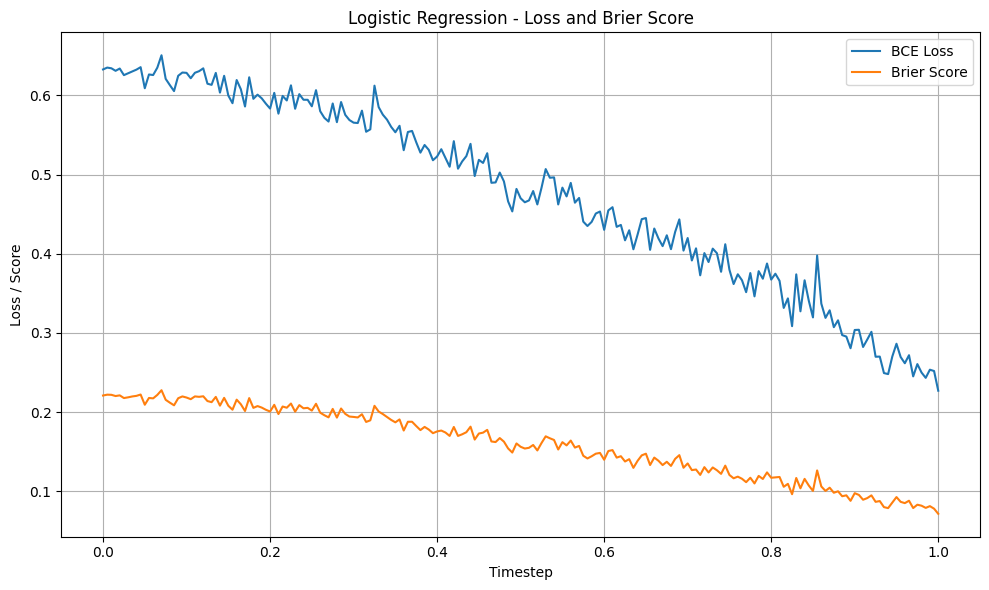

In [7]:
# # Test accuracy of model for each timestep on test data and plot
# accuracies = []
# timesteps = []
import process_data
modules_to_reload = [
    'process_data',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

x = process_data.plot_loss(models, test_data, "Logistic Regression")
# process_data.plot_accuracy(models, test_data, "Logistic Regression")
# process_data.plot_loss(new_models, test_data, "Logistic Regression")

In [ ]:
model = models[0.99]
# features = ["relative_strength", "score_difference", "home_has_possession", "end.down", "end.distance", "end.yardsToEndzone",  "home_timeouts_left", "away_timeouts_left"]
data_point = [0.99, 0.5, -1, 1, 1, 1, 1, 1, 1]
model.predict_proba(np.array([data_point]))

In [156]:
# Save the model
import pickle
filename = 'logistic_regression_model.pickle'
pickle.dump(models, open(filename, 'wb'))

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
%reload_ext autoreload
from models.utils import SHAP_analysis
# model = models[0.99]
# # Health Check:
# if hasattr(model.model, "coef_"):
#     feature_names = model.all_features if hasattr(model, "all_features") else None
#     coefs = model.model.coef_[0]  # shape (n_features,)
#     if feature_names is not None and len(feature_names) == len(coefs):
#         for name, coef in zip(feature_names, coefs):
#             print(f"{name}: {coef}")

SHAP_analysis(models, training_data, test_data, "logistic_regression", "shap_values/LR_possession_probs", timesteps_size=0.1, num_threads = 5)
# x = np.array([[0.1, 0.9, 20, 1, 0, 1, 50, 20, 2, 2, 2]])
# model.predict_proba(x)


In [8]:
from process_data import write_predictions
interpolated_dir = os.path.join(parent_dir, "dataset_interpolated_fixed")
write_predictions(models, interpolated_dir, [2024, 2025], 0, features, replace_nan_val = 0, phat_b = "LR_phat_b")

Loading data for 2025
Processed file:  game_401772888.csv
Processed file:  game_401772863.csv
Processed file:  game_401772877.csv
Processed file:  game_401772730.csv
Processed file:  game_401772724.csv
Processed file:  game_401772718.csv
Processed file:  game_401772917.csv
Processed file:  game_401772903.csv
Processed file:  game_401772902.csv
Processed file:  game_401772916.csv
Processed file:  game_401772719.csv
Processed file:  game_401772725.csv
Processed file:  game_401772731.csv
Processed file:  game_401772876.csv
Processed file:  game_401772862.csv
Processed file:  game_401772889.csv
Processed file:  game_401772848.csv
Processed file:  game_401772874.csv
Processed file:  game_401772860.csv
Processed file:  game_401772727.csv
Processed file:  game_401772733.csv
Processed file:  game_401772928.csv
Processed file:  game_401772900.csv
Processed file:  game_401772914.csv
Processed file:  game_401772915.csv
Processed file:  game_401772901.csv
Processed file:  game_401772929.csv
Proces

In [9]:
import os
import shutil

# Define the ancestor directory and the parent directory
src_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
dest_dir = os.path.abspath(os.path.join(os.getcwd(), "../../"))

# Specify a list of directories to copy
sources = [
    os.path.join(src_dir, "dataset_interpolated_fixed", "2024"),
    os.path.join(src_dir, "dataset_interpolated_fixed", "2025")
]

destination = os.path.join(dest_dir, "test_final", "LR_model")

# Iterate through each source and copy
for source in sources:
    if os.path.exists(source):
        # Extract the year/folder name from source
        folder_name = os.path.basename(source)
        
        if os.path.isdir(source):
            shutil.copytree(source, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(source, destination)
        print(f"Copied '{source}' to '{destination}'")
    else:
        print(f"Source '{source}' does not exist")

Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2024' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_final/LR_model'
Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2025' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_final/LR_model'
